In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/PCA_transformed_final_data.csv")

df.drop(["Unnamed: 0" , "id" , "sequence"], axis = 1, inplace = True)

df = df.dropna()
df.sample()

,Host,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9
5927,Canis lupus familiaris,0.276977,-0.126857,0.000562,-0.01136,-0.009299,-0.019852,-0.013407,0.023522,0.003353,-0.015327


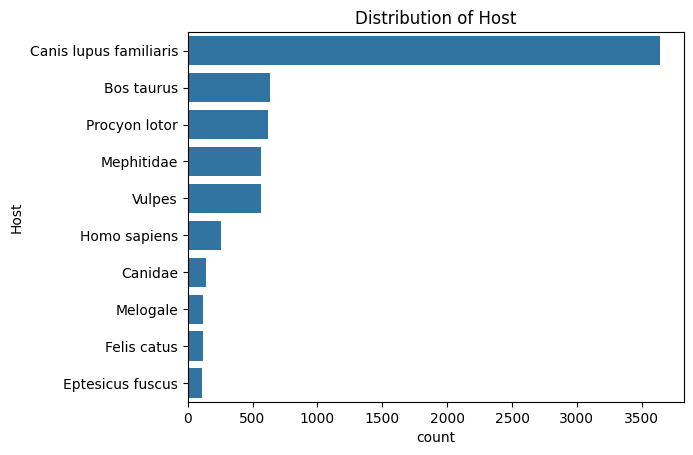

In [ ]:
plt.figure()
sns.countplot(df["Host"], order = df["Host"].value_counts().index)
plt.title("Distribution of Host")
plt.show()

In [ ]:
le = LabelEncoder()

df["Host"] = le.fit_transform(df["Host"])

In [ ]:
df.head()

,Host,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9
0,5,0.106644,-0.107226,0.019644,0.017027,0.028785,-0.015736,0.030065,0.025175,-0.038013,-0.000475
1,5,0.119049,-0.114716,0.018021,0.016783,0.029486,-0.015731,0.033411,0.024482,-0.035317,0.001483
2,5,0.113497,-0.112016,0.018896,0.016447,0.030120,-0.017453,0.034994,0.024927,-0.033269,-0.000157
3,2,0.147459,-0.105213,0.014622,0.009625,0.034623,-0.019460,0.031782,0.023305,-0.018860,0.000942
4,2,0.122030,-0.111838,0.017666,0.016175,0.025688,-0.014404,0.032326,0.024245,-0.035777,0.001708


In [ ]:
y = df["Host"]
x = df.drop("Host" , axis = 1)

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state = 42)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.54      0.52      0.53       117
           1       0.00      0.00      0.00        30
           2       0.74      0.98      0.84       730
           3       0.00      0.00      0.00        22
           4       0.00      0.00      0.00        27
           5       0.00      0.00      0.00        51
           6       0.00      0.00      0.00        25
           7       0.70      0.42      0.53       109
           8       0.72      0.98      0.83       135
           9       0.25      0.04      0.07       107

    accuracy                           0.71      1353
   macro avg       0.29      0.29      0.28      1353
weighted avg       0.59      0.71      0.63      1353



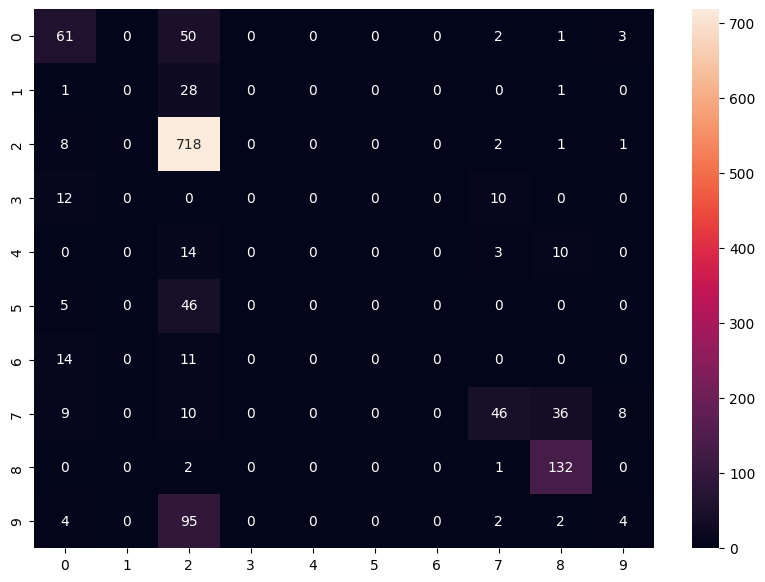

In [22]:
log_reg = LogisticRegression()
log_reg.fit(xtrain, ytrain)

ypred = log_reg.predict(xtest)

print(classification_report(ytest, ypred))

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(ytest, ypred), annot = True, fmt='d')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.89      0.50      0.64       117
           1       0.00      0.00      0.00        30
           2       0.81      0.98      0.88       730
           3       0.71      1.00      0.83        22
           4       0.00      0.00      0.00        27
           5       0.00      0.00      0.00        51
           6       0.95      0.72      0.82        25
           7       0.77      0.47      0.58       109
           8       0.72      0.98      0.83       135
           9       0.65      0.62      0.63       107

    accuracy                           0.79      1353
   macro avg       0.55      0.53      0.52      1353
weighted avg       0.73      0.79      0.74      1353



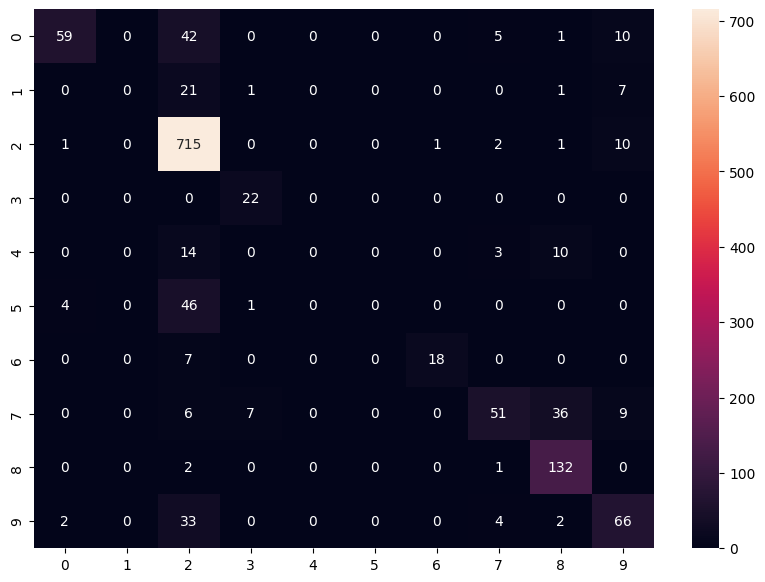

In [23]:
svm = SVC()

svm.fit(xtrain, ytrain)

ypred = svm.predict(xtest)

print(classification_report(ytest, ypred))

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(ytest, ypred), annot = True, fmt = 'd')
plt.show()

              precision    recall  f1-score   support

           0       0.87      0.63      0.73       117
           1       0.61      0.37      0.46        30
           2       0.87      0.96      0.92       730
           3       0.86      0.86      0.86        22
           4       0.33      0.11      0.17        27
           5       0.80      0.31      0.45        51
           6       1.00      1.00      1.00        25
           7       0.74      0.61      0.67       109
           8       0.73      0.92      0.82       135
           9       0.81      0.81      0.81       107

    accuracy                           0.84      1353
   macro avg       0.76      0.66      0.69      1353
weighted avg       0.83      0.84      0.82      1353



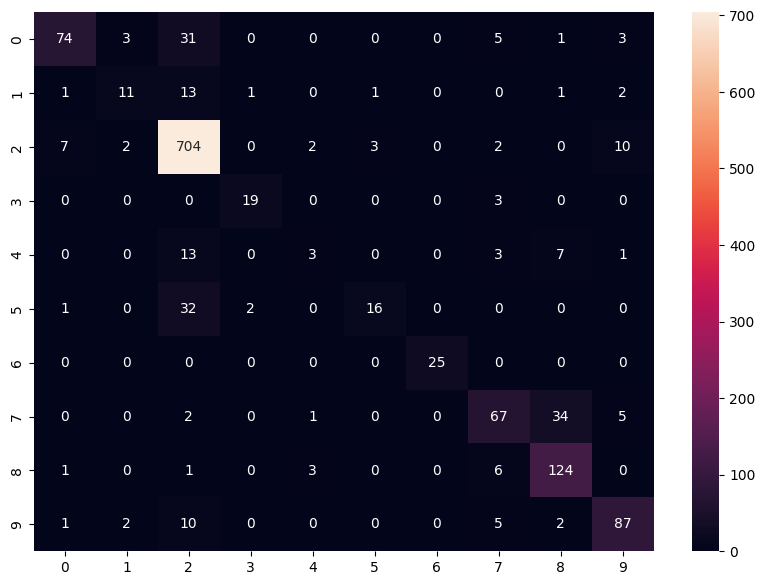

In [24]:
rf = RandomForestClassifier()

rf.fit(xtrain, ytrain)

ypred = rf.predict(xtest)

print(classification_report(ytest, ypred))

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(ytest, ypred), annot = True, fmt = 'd')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann = Sequential()

ann.add(Dense(units = 64, activation = "relu", input_shape = (xtrain.shape[1],)))
ann.add(Dense(units = 32, activation = "relu"))
ann.add(Dense(units = 16, activation = "relu"))
ann.add(Dense(units = 8, activation = "relu"))
ann.add(Dense(units = 1, activation = "softmax"))

ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

ann.fit(xtrain, ytrain, batch_size=32, epochs=50, validation_data=(xtest, ytest))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


158/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0212 - loss: 0.0000e+00

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0212 - loss: 0.0000e+00 - val_accuracy: 0.0221 - val_loss: 0.0000e+00
Epoch 2/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0224 - loss: 0.0000e+00 - val_accuracy: 0.0221 - val_loss: 0.0000e+00
Epoch 3/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0194 - loss: 0.0000e+00 - val_accuracy: 0.0221 - val_loss: 0.0000e+00
Epoch 4/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0211 - loss: 0.0000e+00 - val_accuracy: 0.0221 - val_loss: 0.0000e+00
Epoch 5/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0208 - loss: 0.0000e+00 - val_accuracy: 0.0221 - val_loss: 0.0000e+00
Epoch 6/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0201 - loss: 0.0000e+00 - val_accuracy: 0.0221 - val_loss: 0.0000e+00
Epoch 7/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0201 - loss: 0.0000e+00 - val_accuracy: 0.0221 - val_loss: 0.0000e+00
Epoch 8/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accur

In [ ]:
import pickle

pickle.dump(log_reg, open("log_reg.pkl", "wb"))
pickle.dump(svm, open("svm.pkl", "wb"))
pickle.dump(rf, open("rf.pkl", "wb"))